## Support Vector Classifer Implementation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## lets create synthetic data points
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_samples = 1000,n_features = 2,n_classes = 2,n_clusters_per_class = 2,n_redundant = 0)

In [4]:
X

array([[ 0.59097364,  0.34944429],
       [ 1.69197789, -2.07021023],
       [-0.07568808,  0.7237164 ],
       ...,
       [ 0.67283708,  2.43899081],
       [-0.70837377, -0.83604184],
       [ 1.04230856,  0.91840658]])

In [5]:
y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,

In [6]:
pd.DataFrame(X)[0]

0      0.590974
1      1.691978
2     -0.075688
3      1.115572
4     -0.853410
         ...   
995   -2.844047
996    0.365464
997    0.672837
998   -0.708374
999    1.042309
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

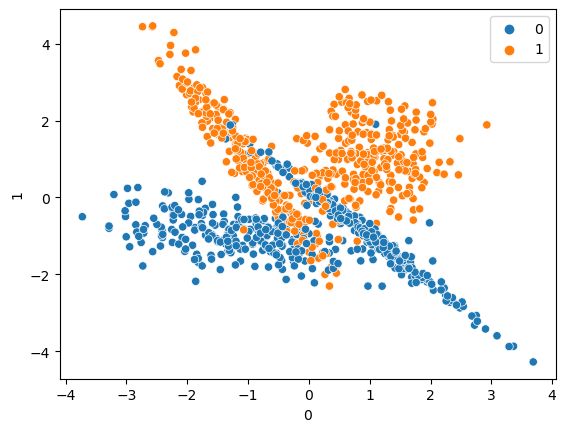

In [15]:
sns.scatterplot(x=pd.DataFrame(X)[0],y = pd.DataFrame(X)[1],hue=y)

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=10)

In [17]:
from sklearn.svm import SVC 

In [18]:
svc = SVC(kernel='linear')

In [19]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [20]:
svc.coef_

array([[0.33023003, 1.4855658 ]])

In [21]:
## Prediction
y_pred = svc.predict(X_test)

In [24]:
from sklearn.metrics import  classification_report,confusion_matrix

In [25]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       116
           1       0.86      0.81      0.84       134

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

[[ 98  18]
 [ 25 109]]


## Hyperparametere Tuning With SVC

In [26]:
from sklearn.model_selection import GridSearchCV

# Defining parameter range 
param_grid = {'C':[0,1,1,10,100,1000],
             'gamma':[1,0.1,0.01,0.001,0.0001],}

In [28]:
grid = GridSearchCV(SVC(),param_grid = param_grid,refit = True,cv= 5,verbose = 3)

In [29]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ........................C=0, gamma=1;, score=nan total time=   0.0s
[CV 2/5] END ........................C=0, gamma=1;, score=nan total time=   0.0s
[CV 3/5] END ........................C=0, gamma=1;, score=nan total time=   0.0s
[CV 4/5] END ........................C=0, gamma=1;, score=nan total time=   0.0s
[CV 5/5] END ........................C=0, gamma=1;, score=nan total time=   0.0s
[CV 1/5] END ......................C=0, gamma=0.1;, score=nan total time=   0.0s
[CV 2/5] END ......................C=0, gamma=0.1;, score=nan total time=   0.0s
[CV 3/5] END ......................C=0, gamma=0.1;, score=nan total time=   0.0s
[CV 4/5] END ......................C=0, gamma=0.1;, score=nan total time=   0.0s
[CV 5/5] END ......................C=0, gamma=0.1;, score=nan total time=   0.0s
[CV 1/5] END .....................C=0, gamma=0.01;, score=nan total time=   0.0s
[CV 2/5] END .....................C=0, gamma=0.

[CV 5/5] END .................C=100, gamma=0.01;, score=0.840 total time=   0.0s
[CV 1/5] END ................C=100, gamma=0.001;, score=0.880 total time=   0.0s
[CV 2/5] END ................C=100, gamma=0.001;, score=0.913 total time=   0.0s
[CV 3/5] END ................C=100, gamma=0.001;, score=0.913 total time=   0.0s
[CV 4/5] END ................C=100, gamma=0.001;, score=0.847 total time=   0.0s
[CV 5/5] END ................C=100, gamma=0.001;, score=0.847 total time=   0.0s
[CV 1/5] END ...............C=100, gamma=0.0001;, score=0.880 total time=   0.0s
[CV 2/5] END ...............C=100, gamma=0.0001;, score=0.907 total time=   0.0s
[CV 3/5] END ...............C=100, gamma=0.0001;, score=0.913 total time=   0.0s
[CV 4/5] END ...............C=100, gamma=0.0001;, score=0.827 total time=   0.0s
[CV 5/5] END ...............C=100, gamma=0.0001;, score=0.860 total time=   0.0s
[CV 1/5] END ...................C=1000, gamma=1;, score=0.907 total time=   0.0s
[CV 2/5] END ...............

C:\Users\Rameshbhai patel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
25 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Rameshbhai patel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Rameshbhai patel\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Rameshbhai patel\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0, 1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001]},
             verbose=3)

In [30]:
grid.best_params_

{'C': 100, 'gamma': 1}

In [32]:
## Prediction
y_pred4 = grid.predict(X_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       116
           1       0.93      0.95      0.94       134

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[107   9]
 [  7 127]]


NameError: name 'accuracy_score' is not defined